In [1]:
import warnings
warnings.simplefilter("ignore")
import numpy as np
import matplotlib.pyplot as plt
from lightkurve import search_lightcurve
from scipy.ndimage import gaussian_filter1d
from astropy.stats import sigma_clip
from scipy.optimize import curve_fit
import batman

# Configurações globais de plotagem
for att in ['axes.labelsize', 'axes.titlesize', 'legend.fontsize', 'xtick.labelsize', 'ytick.labelsize']:
    plt.rcParams[att] = 10

print("="*60)
print("INICIANDO PIPELINE: AU MIC (Planetas b e c)")
print("="*60)

# ============================================================
# PASSO 1 e 2: FUNÇÕES DO MODELO ROTACIONAL (Limpeza da Estrela)
# ============================================================
def gerar_modelo_rotacional_cadencia(t, f, mask_good_flares, cadencia_s=120, janela_horas=10, sigma_clip_val=1.5):
    pontos_por_hora = 3600 / cadencia_s
    janela_pontos = int(janela_horas * pontos_por_hora)
    sigma_pontos = janela_pontos / 8
    
    quebras = list(np.where(np.diff(t) > (20 / (24 * 60)))[0] + 1)
    seg_inicios = [0] + quebras
    seg_fins    = quebras + [len(t)]
    
    modelo_final = np.zeros_like(f)
    
    for i0, i1 in zip(seg_inicios, seg_fins):
        t_seg, f_seg, mask_seg = t[i0:i1], f[i0:i1], mask_good_flares[i0:i1]
        if len(t_seg) < janela_pontos / 4:
            modelo_final[i0:i1] = np.nanmedian(f_seg)
            continue
            
        f_limpo = np.copy(f_seg)
        for _ in range(10):
            temp_smooth = gaussian_filter1d(f_limpo, sigma=sigma_pontos, mode='nearest')
            clipped = sigma_clip(f_seg - temp_smooth, sigma_lower=10.0, sigma_upper=sigma_clip_val, maxiters=1, cenfunc='median', stdfunc='mad_std')            
            f_limpo[clipped.mask] = temp_smooth[clipped.mask]
            f_limpo[~mask_seg] = temp_smooth[~mask_seg] 
            
        modelo_final[i0:i1] = gaussian_filter1d(f_limpo, sigma=sigma_pontos, mode='nearest')
    return modelo_final

def ajustar_trecho_especifico(t, f, mask_good_flares, t_inicio, t_fim, cadencia_s=120, janela_horas=5, sigma_upper=2.0, sigma_lower=2.0, iteracoes=6):
    buffer_dias = (janela_horas * 1.5) / 24.0 
    idx_calc = np.where((t >= t_inicio - buffer_dias) & (t <= t_fim + buffer_dias))[0]
    idx_alvo = np.where((t >= t_inicio) & (t <= t_fim))[0]
    if len(idx_alvo) == 0: return idx_alvo, np.array([])

    t_calc, f_calc, mask_calc = t[idx_calc], f[idx_calc], mask_good_flares[idx_calc]
    sigma_pontos = (janela_horas * (3600 / cadencia_s)) / 8
    f_limpo = np.copy(f_calc)
    
    for _ in range(iteracoes):
        temp_smooth = gaussian_filter1d(f_limpo, sigma=sigma_pontos, mode='reflect')
        clipped = sigma_clip(f_calc - temp_smooth, sigma_lower=sigma_lower, sigma_upper=sigma_upper, maxiters=1, cenfunc='median', stdfunc='mad_std')
        mascara_combinada = (~clipped.mask) & mask_calc
        t_bons, f_bons = t_calc[mascara_combinada], f_limpo[mascara_combinada]
        if len(t_bons) > 2: f_limpo = np.interp(t_calc, t_bons, f_bons)
        else: f_limpo[clipped.mask] = temp_smooth[clipped.mask]
            
    modelo_calc = gaussian_filter1d(f_limpo, sigma=sigma_pontos, mode='nearest')
    return idx_alvo, modelo_calc[np.where(idx_calc == idx_alvo[0])[0][0] : np.where(idx_calc == idx_alvo[-1])[0][0] + 1]

def ajustar_trecho_linear(t, f, mask_good_flares, t_inicio, t_fim, sigma_upper=2.0, sigma_lower=3.0, offset_y=0.0, tilt=0.0):
    idx_alvo = np.where((t >= t_inicio) & (t <= t_fim))[0]
    if len(idx_alvo) == 0: return idx_alvo, np.array([])

    t_alvo, f_alvo = t[idx_alvo], f[idx_alvo]
    t_limpo, f_limpo = t_alvo[mask_good_flares[idx_alvo]], f_alvo[mask_good_flares[idx_alvo]]
    clipped = sigma_clip(f_limpo, sigma_lower=sigma_lower, sigma_upper=sigma_upper, maxiters=2)
    bons = ~clipped.mask

    if np.sum(bons) > 2:
        coefs = np.polyfit(t_limpo[bons], f_limpo[bons], deg=1)
        t_centro = np.mean(t_alvo)
        modelo_linear = (coefs[0] + tilt) * (t_alvo - t_centro) + np.polyval(coefs, t_centro) + offset_y
    else:
        modelo_linear = (np.ones_like(t_alvo) * np.nanmedian(f_alvo)) + offset_y
    return idx_alvo, modelo_linear

def costurar_bordas(t, modelo, bordas, tamanho_janela=25, sigma_gauss=0):
    modelo_costurado = np.copy(modelo).astype(float)
    for borda_idx in sorted(bordas):
        inicio, fim = max(0, borda_idx - tamanho_janela), min(len(t) - 1, borda_idx + tamanho_janela)
        if (fim - inicio) < 10: continue
        meia_zona = (fim - inicio) // 4
        fim_esq, ini_dir = max(inicio + 2, borda_idx - meia_zona), min(fim - 2, borda_idx + meia_zona)
        idx_esq, idx_dir = np.arange(inicio, fim_esq), np.arange(ini_dir, fim + 1)
        if len(idx_esq) < 5 or len(idx_dir) < 5: continue
            
        t_centro = t[borda_idx]
        poly_esq = np.polyfit(t[idx_esq] - t_centro, modelo_costurado[idx_esq], deg=2)
        poly_dir = np.polyfit(t[idx_dir] - t_centro, modelo_costurado[idx_dir], deg=2)
        
        zona_miolo = np.arange(fim_esq, ini_dir + 1)
        t_miolo = t[zona_miolo] - t_centro
        x_norm = np.clip((t[zona_miolo] - t[fim_esq]) / (t[ini_dir] - t[fim_esq] + 1e-10), 0, 1)
        peso = 3 * x_norm**2 - 2 * x_norm**3 
        modelo_costurado[zona_miolo] = (1 - peso) * np.polyval(poly_esq, t_miolo) + peso * np.polyval(poly_dir, t_miolo)
        
    if sigma_gauss > 0:
        quebras = list(np.where(np.diff(t) > np.median(np.diff(t)) * 5)[0] + 1)
        for i0, i1 in zip([0] + quebras, quebras + [len(t)]):
            if len(modelo_costurado[i0:i1]) > 1:
                modelo_costurado[i0:i1] = gaussian_filter1d(modelo_costurado[i0:i1], sigma=sigma_gauss)
    return modelo_costurado

def ajustar_trecho_polinomial(t, f, mask_good_flares, t_inicio, t_fim, grau, sigma_upper=2.0, sigma_lower=2.0):
    """
    Ajusta um polinômio local para preservar trânsitos, isolando a região do trânsito 
    e ajustando a linha de base aos pontos fora dele usando sigma clipping.
    """
    idx_alvo = np.where((t >= t_inicio) & (t <= t_fim))[0]
    
    # Se a região não estiver nos dados (ex: gap de observação), retorna vazio
    if len(idx_alvo) == 0: 
        return idx_alvo, np.array([])

    t_alvo = t[idx_alvo]
    f_alvo = f[idx_alvo]
    
    # Aplica a máscara inicial de flares
    t_limpo = t_alvo[mask_good_flares[idx_alvo]]
    f_limpo = f_alvo[mask_good_flares[idx_alvo]]
    
    # O sigma_clip inferior (sigma_lower) é vital aqui para ignorar o trânsito 
    # durante o ajuste do polinômio da estrela
    clipped = sigma_clip(f_limpo, sigma_lower=sigma_lower, sigma_upper=sigma_upper, maxiters=2)
    bons = ~clipped.mask

    # Precisamos de pontos suficientes para ajustar o polinômio do grau exigido
    if np.sum(bons) > grau + 1:
        # Centralizamos o tempo para evitar instabilidade numérica na matriz do polinômio
        t_centro = np.mean(t_alvo)
        coefs = np.polyfit(t_limpo[bons] - t_centro, f_limpo[bons], deg=grau)
        modelo_poly = np.polyval(coefs, t_alvo - t_centro)
    else:
        # Fallback de segurança se o clipping remover dados demais
        modelo_poly = np.ones_like(t_alvo) * np.nanmedian(f_alvo)
        
    return idx_alvo, modelo_poly
# --- EXECUÇÃO: DOWNLOAD E LIMPEZA ---
print("\nBuscando e baixando dados de AU Mic do MAST...")
search_result = search_lightcurve("AU Mic")
indices_alvo = [0, 2] # Setores 1 e 27

t_todos, f_todos, modelo_todos, residuo_todos = [], [], [], []

regioes_ajuste_local = [
    [3884.6271, 3884.9503, 10.0, 1.2, 3.0, 12], [3885.9927, 3886.4632, 10.0, 5, 5.0, 12], [3900.1457, 3901.0141, 10.0, 0.8, 0.8, 10],
    [1330.2440, 1330.6343, 8, 1.2, 1.0, 12],[1347.0770, 1347.662, 20, 1.2, 1.0, 10],[2041.013, 2041.4180, 10, 1.2, 1.0, 200],    [3902.9503, 3903.4152, 10.0, 0.8, 0.8, 10],
    [2057.991, 2058.425, 8, 1.2, 1.0, 12],    #[3886.9927, 3886.4709, 8.0, 5, 5.0, 12]
    
   # ,


]
## Ajustes Polinomiais EXCLUSIVOS para proteger os trânsitos (graus 3 ou 4)
regioes_ajuste_polinomial = [
    #[1330.2440, 1330.6343, 3, 2.0, 0.5],
    #[1347.0770, 1347.6620, 3, 2.0, 0.5],
    #[2041.0130, 2041.4180, 4, 2.0, 0.5],
    [2049.4540, 2049.9840, 4, 2.0, 0.5],
    [3886.9927, 3886.4709, 3, 2.0, 0.5]
    #[2057.991, 2058.425, 2, 2.0, 0.5] ,
]

regioes_ajuste_linear = [
    [3906.9180, 3907.1300, 15.5, 9.0, 0.0001, 0.0005]
]

for idx in indices_alvo:
    print(f"A processar Índice de Busca [{idx}]...")
    lc = search_result[idx].download().remove_nans().remove_outliers()
    lc = lc[lc.quality == 0].normalize().remove_nans()

    t_sec = np.ascontiguousarray(lc.time.value, dtype=np.float64)
    f_sec = np.ascontiguousarray(lc.flux, dtype=np.float64)
    
    # Máscara para evitar que o modelo siga flares
    mask_good_flares = (f_sec - gaussian_filter1d(f_sec, sigma=15)) < (3 * np.nanstd(f_sec - gaussian_filter1d(f_sec, sigma=15)))
    
    # Gera o modelo base (onde o erro dos trânsitos ocorria)
    modelo_manchas = gerar_modelo_rotacional_cadencia(t_sec, f_sec, mask_good_flares, cadencia_s=120, janela_horas=10, sigma_clip_val=1.8)
    bordas_indices = set()

    # 1. Aplica Ajustes Locais (Anomalias Gerais da Estrela)
    for ini, fim, janela_h, sig_up, sig_low, iters in regioes_ajuste_local:
        if np.any((t_sec >= ini) & (t_sec <= fim)):
            idx_alvo, mod_local = ajustar_trecho_especifico(t_sec, f_sec, mask_good_flares, ini, fim, 120, janela_h, sig_up, sig_low, iters)
            if len(idx_alvo) > 0:
                modelo_manchas[idx_alvo] = mod_local
                bordas_indices.update([idx_alvo[0], idx_alvo[-1]])

    # 2. Aplica Ajustes Polinomiais (Proteção dos Trânsitos)
    for ini, fim, grau, sig_up, sig_low in regioes_ajuste_polinomial:
        if np.any((t_sec >= ini) & (t_sec <= fim)):
            idx_alvo, mod_poly = ajustar_trecho_polinomial(t_sec, f_sec, mask_good_flares, ini, fim, grau, sig_up, sig_low)
            
            if len(idx_alvo) > 30: # Garante que tem tamanho suficiente para suavizar
                # Define quantos pontos vão se misturar nas pontas (aprox 30-40 minutos em cadência de 120s)
                pontos_blend = 15 
                
                mod_antigo = np.copy(modelo_manchas[idx_alvo])
                mod_novo = np.copy(mod_poly)
                
                # Cria rampas de transição suave (de 0 a 1)
                fade_in = np.linspace(0, 1, pontos_blend)
                fade_out = np.linspace(1, 0, pontos_blend)
                
                # Mistura o modelo velho com o novo apenas nas extremidades
                mod_novo[:pontos_blend] = mod_antigo[:pontos_blend] * (1 - fade_in) + mod_novo[:pontos_blend] * fade_in
                mod_novo[-pontos_blend:] = mod_antigo[-pontos_blend:] * (1 - fade_out) + mod_novo[-pontos_blend:] * fade_out
                
                # Aplica o modelo misturado no vetor principal
                modelo_manchas[idx_alvo] = mod_novo
                
                # Como já fizemos a transição perfeita, não precisamos mais mandar o idx_alvo pras bordas_indices
    # 3. Aplica Ajustes Lineares
    for ini, fim, sig_up, sig_low, off_y, tilt_val in regioes_ajuste_linear:
        if np.any((t_sec >= ini) & (t_sec <= fim)):
            idx_alvo, mod_linear = ajustar_trecho_linear(t_sec, f_sec, mask_good_flares, ini, fim, sig_up, sig_low, off_y, tilt_val)
            if len(idx_alvo) > 0:
                modelo_manchas[idx_alvo] = mod_linear
                bordas_indices.update([idx_alvo[0], idx_alvo[-1]])

    # Costura suave das correções com o resto da curva
    if len(bordas_indices) > 0:
        modelo_manchas_suave = costurar_bordas(t_sec, modelo_manchas, sorted(list(bordas_indices)), 25, 3)
    else:
        modelo_manchas_suave = np.copy(modelo_manchas)
        quebras = list(np.where(np.diff(t_sec) > np.median(np.diff(t_sec)) * 5)[0] + 1)
        for i0, i1 in zip([0] + quebras, quebras + [len(t_sec)]):
            if i1 - i0 > 1: modelo_manchas_suave[i0:i1] = gaussian_filter1d(modelo_manchas_suave[i0:i1], sigma=3)

    # Guarda os resultados com os trânsitos preservados
    t_todos.append(t_sec)
    f_todos.append(f_sec)
    modelo_todos.append(modelo_manchas_suave)
    residuo_todos.append(f_sec / modelo_manchas_suave)

# ============================================================
# RESÍDUOS SEPARADOS POR SETOR (sem concatenar)
# posição 0 -> Setor 1  |  posição 1 -> Setor 27
# ============================================================
t_setor1,  residuo_setor1  = t_todos[0], residuo_todos[0]
t_setor27, residuo_setor27 = t_todos[1], residuo_todos[1]

# Acesso opcional por dicionário (nome do setor -> posição na lista)
setores = {1: 0, 27: 1}
t_por_setor       = {s: t_todos[i]       for s, i in setores.items()}
residuo_por_setor = {s: residuo_todos[i] for s, i in setores.items()}

print("\nLimpeza concluída! Resíduos separados por setor (1 e 27), trânsitos preservados.")

INICIANDO PIPELINE: AU MIC (Planetas b e c)

Buscando e baixando dados de AU Mic do MAST...
A processar Índice de Busca [0]...
A processar Índice de Busca [2]...

Limpeza concluída! Resíduos separados por setor (1 e 27), trânsitos preservados.


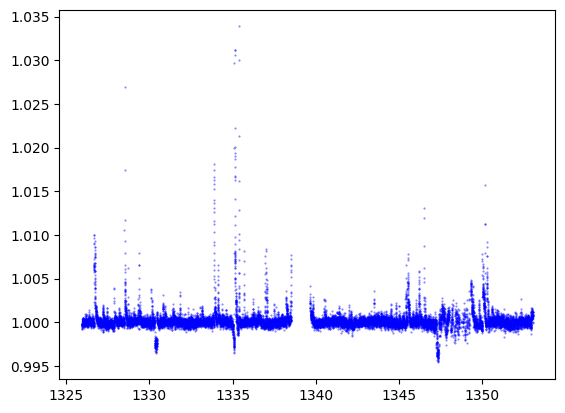

In [2]:
plt.plot(t_setor1, residuo_setor1, '.', markersize=1, color='blue', alpha=0.5, label='Setor 1')
plt.show()

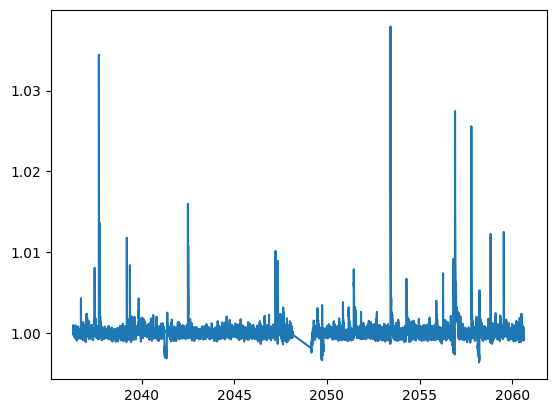

In [3]:
plt.plot(t_setor27, residuo_setor27)
plt.show() 


In [4]:
t_setor95, residuo_setor95 = np.loadtxt("residuo_setor95.txt", unpack=True)

In [5]:
%matplotlib qt
plt.plot(t_setor95, residuo_setor95)
plt.show() 

In [6]:
# ============================================================
# EXTRAÇÃO DOS TRÂNSITOS AU MIC b A PARTIR DOS 3 SETORES
# ============================================================
%matplotlib qt

# Efeméride de referência (usa a tua NEW/OLD conforme preferir)
P_ref  = 8.4631516
T0_ref = 1330.39046      # BTJD
janela = 0.15            # ±dias em torno do meio do trânsito

setores = [
    ("Setor 1  (2018)", t_setor1,  residuo_setor1),
    ("Setor 27 (2020)", t_setor27, residuo_setor27),
    ("Setor 95 (2025)", t_setor95, residuo_setor95),
]

trechos = []
for origem, t_s, r_s in setores:
    # épocas possíveis dentro do intervalo desse setor
    n_min = int(np.floor((t_s.min() - T0_ref) / P_ref))
    n_max = int(np.ceil ((t_s.max() - T0_ref) / P_ref))

    for epoch in range(n_min, n_max + 1):
        Tc = T0_ref + epoch * P_ref
        mask = (t_s >= Tc - janela) & (t_s <= Tc + janela)
        if mask.sum() < 20:          # descarta trânsito faltando (gap/borda)
            continue
        trechos.append({
            't'     : t_s[mask],
            'flux'  : r_s[mask],
            'epoch' : epoch,
            'origem': origem,
        })

trechos.sort(key=lambda x: x['epoch'])
print(f"Total de trânsitos recuperados: {len(trechos)}")
for tr in trechos:
    print(f"  Época {tr['epoch']:>3d}  |  {tr['origem']}  |  {len(tr['t'])} pontos")

# ============================================================
# VISUALIZAÇÃO: trânsitos sobrepostos (entrada do MCMC)
# ============================================================
def fase_dias(t_arr, T0, P):
    ph = ((t_arr - T0) / P + 0.5) % 1 - 0.5   # fase em [-0.5, 0.5]
    return ph * P                              # de volta para dias

fig, ax = plt.subplots(figsize=(9, 6))
cores = plt.cm.viridis(np.linspace(0, 0.9, len(trechos)))

for i, tr in enumerate(trechos):
    t_rel = fase_dias(tr['t'], T0_ref, P_ref)
    ax.plot(t_rel, tr['flux'], 'o', ms=3, alpha=0.5, color=cores[i],
            label=f"Época {tr['epoch']} — {tr['origem']}")

ax.axvline(0, color='red', ls='-.', alpha=0.6, label='T0 de referência')
ax.set_xlim(-janela, janela)
ax.set_xlabel('Tempo relativo a T0 (dias)')
ax.set_ylabel('Fluxo Residual')
ax.set_title(f'AU Mic b — {len(trechos)} trânsitos sobrepostos (pré-MCMC)\n'
             f'T0={T0_ref:.6f}   P={P_ref:.6f} d', fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc='lower right')
plt.tight_layout()
plt.show()

Total de trânsitos recuperados: 7
  Época   0  |  Setor 1  (2018)  |  208 pontos
  Época   2  |  Setor 1  (2018)  |  193 pontos
  Época  84  |  Setor 27 (2020)  |  216 pontos
  Época  85  |  Setor 27 (2020)  |  216 pontos
  Época  86  |  Setor 27 (2020)  |  216 pontos
  Época 302  |  Setor 95 (2025)  |  216 pontos
  Época 304  |  Setor 95 (2025)  |  216 pontos


In [7]:
# ============================================================
# EXTRAÇÃO DOS TRÂNSITOS DE AU MIC b NOS 3 SETORES + EMPILHAMENTO
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

P_ref  = 8.4631516
T0_ref = 1330.39051      # BTJD
janela = 0.25            # ± dias em torno do meio do trânsito
dur    = 0.15            # ± dias considerados "dentro" do trânsito (p/ baseline)
MIN_PTS = 20

setores = [
    ("Setor 1  (2018)", t_setor1,  residuo_setor1),
    ("Setor 27 (2020)", t_setor27, residuo_setor27),
    ("Setor 95 (2025)", t_setor95, residuo_setor95),
]

# ---------- 1. extrai trecho de cada época em cada setor ----------
trechos = []
for origem, t_s, r_s in setores:
    t_s = np.asarray(t_s, float)
    r_s = np.asarray(r_s, float)
    ok  = np.isfinite(t_s) & np.isfinite(r_s)
    t_s, r_s = t_s[ok], r_s[ok]

    n_min = int(np.floor((t_s.min() - T0_ref) / P_ref))
    n_max = int(np.ceil ((t_s.max() - T0_ref) / P_ref))

    for epoch in range(n_min, n_max + 1):
        Tc   = T0_ref + epoch * P_ref
        mask = (t_s >= Tc - janela) & (t_s <= Tc + janela)
        if mask.sum() < MIN_PTS:
            continue

        t_tr = t_s[mask]
        f_tr = r_s[mask]
        dt   = t_tr - Tc                     # tempo relativo ao meio do trânsito

        # exige cobertura dos dois lados do trânsito
        if dt.min() > -dur or dt.max() < dur:
            continue

        # normaliza pelo baseline fora de trânsito (deixa tudo em torno de 1)
        oot = np.abs(dt) > dur
        if oot.sum() < 10:
            continue
        base = np.median(f_tr[oot])
        f_norm = f_tr / base if abs(base) > 1e-6 else f_tr - base + 1.0

        trechos.append({'epoch': epoch, 'origem': origem, 'Tc': Tc,
                        't': t_tr, 'dt': dt, 'flux': f_tr, 'flux_norm': f_norm})

trechos.sort(key=lambda x: x['epoch'])
print(f"Total de trânsitos recuperados: {len(trechos)}")
for tr in trechos:
    print(f"  época {tr['epoch']:>3d} | {tr['origem']} | Tc={tr['Tc']:.5f} | {len(tr['t'])} pts")

# ---------- 2. empilha todos ----------
dt_all   = np.concatenate([tr['dt']        for tr in trechos])
flux_all = np.concatenate([tr['flux_norm'] for tr in trechos])
ep_all   = np.concatenate([np.full(len(tr['dt']), tr['epoch']) for tr in trechos])

ordem    = np.argsort(dt_all)
dt_all, flux_all, ep_all = dt_all[ordem], flux_all[ordem], ep_all[ordem]
print(f"\nEmpilhado: {len(dt_all)} pontos de {len(trechos)} trânsitos")

# ---------- 3. binagem do empilhado ----------
def binar(x, y, dx=0.002):
    bins   = np.arange(x.min(), x.max() + dx, dx)
    idx    = np.digitize(x, bins) - 1
    xb, yb, eb = [], [], []
    for i in range(len(bins) - 1):
        m = idx == i
        if m.sum() < 3:
            continue
        xb.append(np.mean(x[m]))
        yb.append(np.median(y[m]))
        eb.append(np.std(y[m]) / np.sqrt(m.sum()))
    return np.array(xb), np.array(yb), np.array(eb)

dt_b, f_b, e_b = binar(dt_all, flux_all, dx=0.002)

# ---------- 4. plot ----------
fig, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

cores = plt.cm.viridis(np.linspace(0, 0.9, len(trechos)))
for i, tr in enumerate(trechos):
    ax[0].plot(tr['dt'], tr['flux_norm'], 'o', ms=2.5, alpha=0.45, color=cores[i],
               label=f"época {tr['epoch']} – {tr['origem']}")
ax[0].axvline(0, color='red', ls='-.', alpha=0.6)
ax[0].set_ylabel('Fluxo normalizado')
ax[0].set_title(f'AU Mic b – {len(trechos)} trânsitos sobrepostos\n'
                f'T0={T0_ref:.6f}  P={P_ref:.7f} d', fontweight='bold')
ax[0].legend(fontsize=7, ncol=2, loc='lower right')
ax[0].grid(alpha=0.3)

ax[1].plot(dt_all, flux_all, '.', ms=2, color='gray', alpha=0.35, label='todos os pontos')
ax[1].errorbar(dt_b, f_b, yerr=e_b, fmt='o', ms=5, color='crimson',
               ecolor='crimson', elinewidth=1, capsize=2, label='empilhado (bins de 2.9 min)')
ax[1].axvline(0, color='red', ls='-.', alpha=0.6)
ax[1].set_xlim(-janela, janela)
ax[1].set_xlabel('Tempo relativo a Tc (dias)')
ax[1].set_ylabel('Fluxo normalizado')
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# arrays prontos para o MCMC:
#   trechos  -> lista com cada trânsito separado
#   dt_all, flux_all, ep_all  -> empilhado ponto a ponto
#   dt_b, f_b, e_b            -> empilhado binado


Total de trânsitos recuperados: 7
  época   0 | Setor 1  (2018) | Tc=1330.39051 | 352 pts
  época   2 | Setor 1  (2018) | Tc=1347.31681 | 307 pts
  época  84 | Setor 27 (2020) | Tc=2041.29524 | 360 pts
  época  85 | Setor 27 (2020) | Tc=2049.75840 | 360 pts
  época  86 | Setor 27 (2020) | Tc=2058.22155 | 360 pts
  época 302 | Setor 95 (2025) | Tc=3886.26229 | 359 pts
  época 304 | Setor 95 (2025) | Tc=3903.18860 | 360 pts

Empilhado: 2458 pontos de 7 trânsitos


In [8]:
# ============================================================
# SALVA OS TRÂNSITOS EXTRAÍDOS EM ARQUIVOS .TXT
# ============================================================
import os
import numpy as np

pasta = "transitos_aumic_b"
os.makedirs(pasta, exist_ok=True)

# ---------- 1. um arquivo por trânsito ----------
for tr in trechos:
    setor = ''.join(ch for ch in tr['origem'] if ch.isdigit())
    nome  = os.path.join(pasta, f"transito_ep{tr['epoch']:03d}_setor{setor}.txt")
    dados = np.column_stack([tr['t'], tr['dt'], tr['flux'], tr['flux_norm']])
    np.savetxt(nome, dados, fmt="%.8f",
               header=(f"AU Mic b | epoca={tr['epoch']} | {tr['origem']} | "
                       f"Tc={tr['Tc']:.6f} | T0={T0_ref:.6f} | P={P_ref:.7f}\n"
                       "tempo_BTJD  dt_dias  fluxo_residual  fluxo_normalizado"))
    print("salvo:", nome)

# ---------- 2. arquivo único com TODOS os trânsitos ----------
t_cat    = np.concatenate([tr['t']         for tr in trechos])
dt_cat   = np.concatenate([tr['dt']        for tr in trechos])
f_cat    = np.concatenate([tr['flux']      for tr in trechos])
fn_cat   = np.concatenate([tr['flux_norm'] for tr in trechos])
ep_cat   = np.concatenate([np.full(len(tr['t']), tr['epoch'])          for tr in trechos])
set_cat  = np.concatenate([np.full(len(tr['t']), int(''.join(ch for ch in tr['origem'] if ch.isdigit())))
                           for tr in trechos])

arq_todos = os.path.join(pasta, "todos_transitos_aumic_b.txt")
np.savetxt(arq_todos,
           np.column_stack([t_cat, dt_cat, f_cat, fn_cat, ep_cat, set_cat]),
           fmt=["%.8f", "%.8f", "%.8f", "%.8f", "%d", "%d"],
           header=(f"AU Mic b - todos os transitos extraidos dos setores 1, 27 e 95\n"
                   f"T0_ref={T0_ref:.6f}  P_ref={P_ref:.7f}  janela=+/-{janela} d  "
                   f"N_transitos={len(trechos)}  N_pontos={len(t_cat)}\n"
                   "tempo_BTJD  dt_dias  fluxo_residual  fluxo_normalizado  epoca  setor"))
print("salvo:", arq_todos)

# ---------- 3. empilhado (ponto a ponto e binado) ----------
arq_emp = os.path.join(pasta, "empilhado_aumic_b.txt")
np.savetxt(arq_emp, np.column_stack([dt_all, flux_all, ep_all]),
           fmt=["%.8f", "%.8f", "%d"],
           header=(f"AU Mic b - empilhamento em fase ({len(trechos)} transitos)\n"
                   f"T0_ref={T0_ref:.6f}  P_ref={P_ref:.7f}\n"
                   "dt_dias  fluxo_normalizado  epoca"))
print("salvo:", arq_emp)

arq_bin = os.path.join(pasta, "empilhado_binado_aumic_b.txt")
np.savetxt(arq_bin, np.column_stack([dt_b, f_b, e_b]), fmt="%.8f",
           header=(f"AU Mic b - empilhado binado (bins de 0.002 d)\n"
                   f"T0_ref={T0_ref:.6f}  P_ref={P_ref:.7f}\n"
                   "dt_dias  fluxo_normalizado  erro"))
print("salvo:", arq_bin)

# ---------- 4. resumo dos trânsitos ----------
arq_res = os.path.join(pasta, "resumo_transitos.txt")
with open(arq_res, "w", encoding="utf-8") as fh:
    fh.write(f"# AU Mic b | T0_ref={T0_ref:.6f} | P_ref={P_ref:.7f} | janela=+/-{janela} d\n")
    fh.write(f"# {'epoca':>6s} {'setor':>6s} {'Tc_BTJD':>14s} {'t_ini':>14s} {'t_fim':>14s} {'N_pts':>6s}\n")
    for tr in trechos:
        setor = int(''.join(ch for ch in tr['origem'] if ch.isdigit()))
        fh.write(f"  {tr['epoch']:6d} {setor:6d} {tr['Tc']:14.6f} "
                 f"{tr['t'].min():14.6f} {tr['t'].max():14.6f} {len(tr['t']):6d}\n")
print("salvo:", arq_res)


salvo: transitos_aumic_b\transito_ep000_setor12018.txt
salvo: transitos_aumic_b\transito_ep002_setor12018.txt
salvo: transitos_aumic_b\transito_ep084_setor272020.txt
salvo: transitos_aumic_b\transito_ep085_setor272020.txt
salvo: transitos_aumic_b\transito_ep086_setor272020.txt
salvo: transitos_aumic_b\transito_ep302_setor952025.txt
salvo: transitos_aumic_b\transito_ep304_setor952025.txt
salvo: transitos_aumic_b\todos_transitos_aumic_b.txt
salvo: transitos_aumic_b\empilhado_aumic_b.txt
salvo: transitos_aumic_b\empilhado_binado_aumic_b.txt
salvo: transitos_aumic_b\resumo_transitos.txt
